# Restaurant Rating & Cuisine Analysis data visualization

In [2]:
# import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install pandas numpy matplotlib seaborn

In [4]:
df = pd.read_csv("C:\\Users\\anilr\\OneDrive\\Desktop\\Restaurant_Rating_&_Cuisine_Analysis\\zomato_india_1000_restaurants_cleanning_Data.csv")
df.head()

,Restaurant Name,Rating,Reviews,Cuisine,Address,City,Restaurant URL,Image URL
0,Masala Republic By Dadu's,4.3,3027.0,"Asian, Continental, North Indian","3-6-14/3-5, Himayat Nagar Road, Chandra Nagar ...",Hyderabad,/hyderabad/masala-republic-by-dadus-basheer-ba...,https://b.zmtcdn.com/data/pictures/5/19137785/...
1,Mirame Cafe & Kitchen,4.3,1472.0,"Chinese, North Indian, Cafe","Chikkadpalli Road, Above Union Bank, Chikkadpa...",Hyderabad,/hyderabad/mirame-cafe-kitchen-rtc-x-roads/info,https://b.zmtcdn.com/data/pictures/4/20567554/...
2,Accha Telugu Kitchen & Bar,4.3,1332.0,"South Indian, Fast Food","Hussain Sagar, Opposite Lake Police Station, P...",Hyderabad,/hyderabad/accha-telugu-kitchen-bar-somajiguda...,https://b.zmtcdn.com/images/res_avatar_476_320...
3,The Camp,4.2,1237.0,"Modern Indian, Bar Food, Alcoholic Beverages","9th Floor, Triveni Complex, Abids, Hyderabad",Hyderabad,/hyderabad/the-camp-abids/info,https://b.zmtcdn.com/data/pictures/9/21623459/...
4,Qaffeine Bistro,4.4,247.0,"Continental, Cafe, Pizza","8-2-208/19, Road 10, Banjara Hills, Hyderabad",Hyderabad,/hyderabad/qaffeine-bistro-1-banjara-hills/info,https://b.zmtcdn.com/data/pictures/5/22629775/...


                              Cuisine  Rating
9       American, Pizza, North Indian     4.9
606          Oriental, Chinese, Asian     4.9
496     North Indian, Awadhi, Mughlai     4.8
171                   Burmese, Fusion     4.8
395              Italian, Continental     4.7
294            Continental, Fast Food     4.7
711          Sushi, Chinese, Japanese     4.7
173             Cafe, American, Asian     4.7
684  South Indian, Continental, Asian     4.7
433                     Korean, Asian     4.7


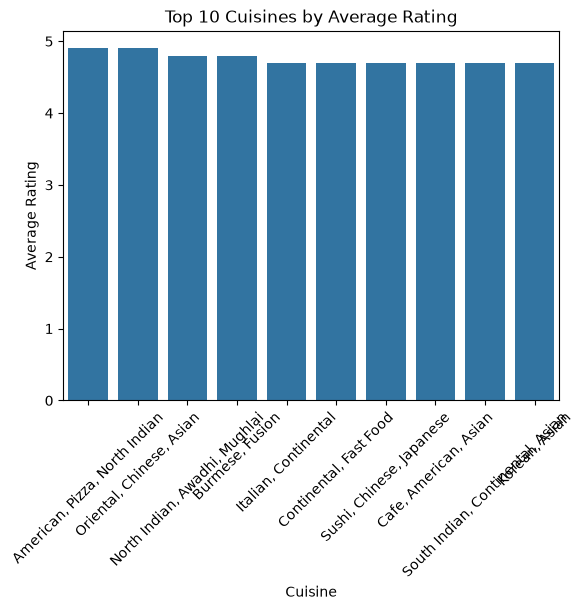

In [5]:
# Get average rating for each cuisine
avg_rating_by_cuisine = (
    df.groupby('Cuisine')['Rating']
      .mean()
      .reset_index()
)

# Select top 10 cuisines
top_10_cuisines = avg_rating_by_cuisine.sort_values(
    by='Rating',
    ascending=False
).head(10)

print(top_10_cuisines)

# Plot top 10 cuisines
sns.barplot(
    data=top_10_cuisines,
    x='Cuisine',
    y='Rating'
)

plt.title('Top 10 Cuisines by Average Rating')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

        City  Restaurant Name
0  Bangalore              496
1  Hyderabad              494
2     Mumbai               10


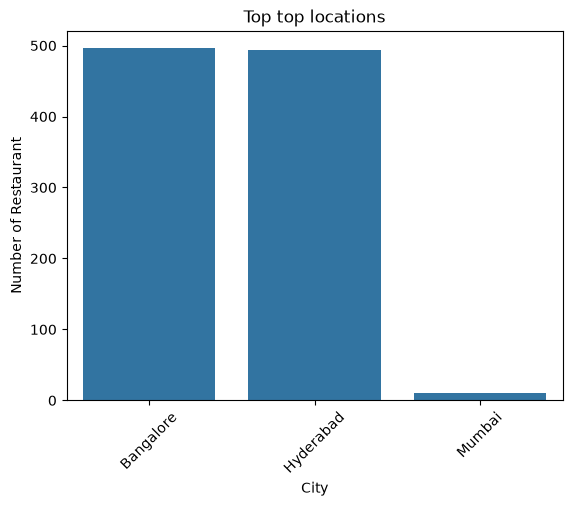

In [6]:
# Top 10 locations with the most restaurants


toplocations = (
    df['City']
    .value_counts()
    .head(10)
    .reset_index()
)


toplocations.columns = ['City', 'Restaurant Name']

print(toplocations)
sns.barplot(data = toplocations,
            x = "City",

            y = "Restaurant Name")
plt.title('Top top locations')
plt.xlabel('City')
plt.ylabel('Number of Restaurant')
plt.xticks(rotation=45)
plt.show()

                            Restaurant Name  Rating
0                         10 Downing Street     4.0
1    1131 Bar + Kitchen By House Of Commons     4.3
2                            1522 - The Pub     4.2
3                          153 Biere Street     4.2
4                                      1947     4.1
..                                      ...     ...
961                      Zythum Brewing Co.     4.3
962   boCHE & Shakesbierre - Brewpub & Club     4.5
963                           ee Kavii Kafe     4.2
964             epulo - Vineyard Restaurant     4.8
965                                   ilili     4.5

[966 rows x 2 columns]


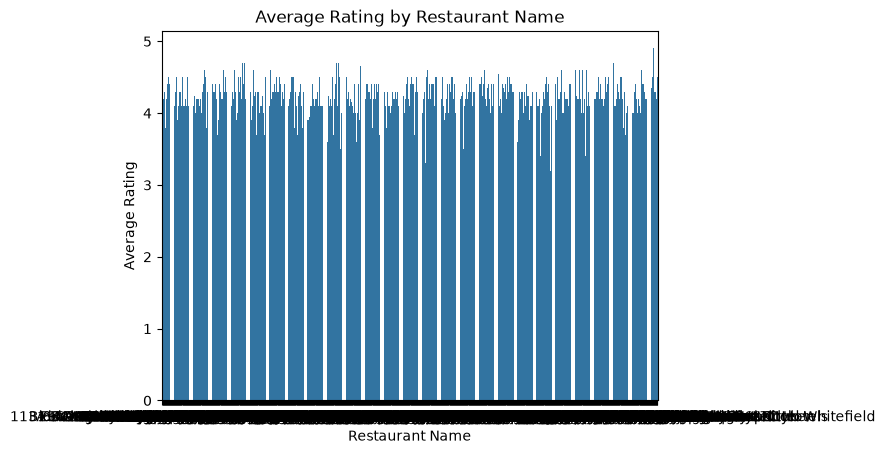

In [12]:
# Average rating for each Restaurant Name

avg_rating_by_price = (
    df.groupby('Restaurant Name')['Rating']
      .mean()
      .reset_index()
)

print(avg_rating_by_price)

sns.barplot(
    data=avg_rating_by_price,
    x='Restaurant Name',
    y='Rating'
)

plt.title('Average Rating by Restaurant Name')
plt.xlabel('Restaurant Name')
plt.ylabel('Average Rating')
plt.show()

# Rating Distribution

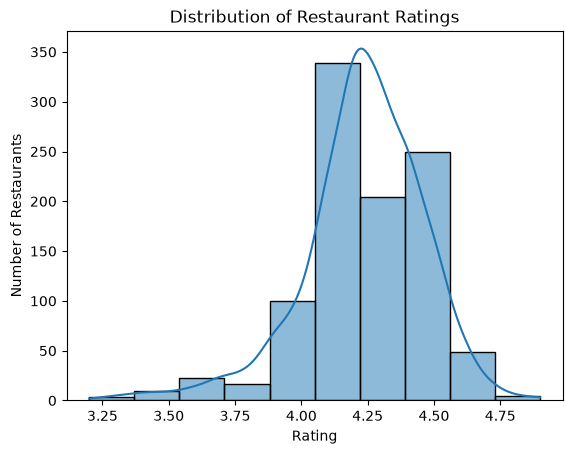

In [ ]:

sns.histplot(data=df, x='Rating', bins=10, kde=True)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

# Average Rating by Cuisine — Bar Plot

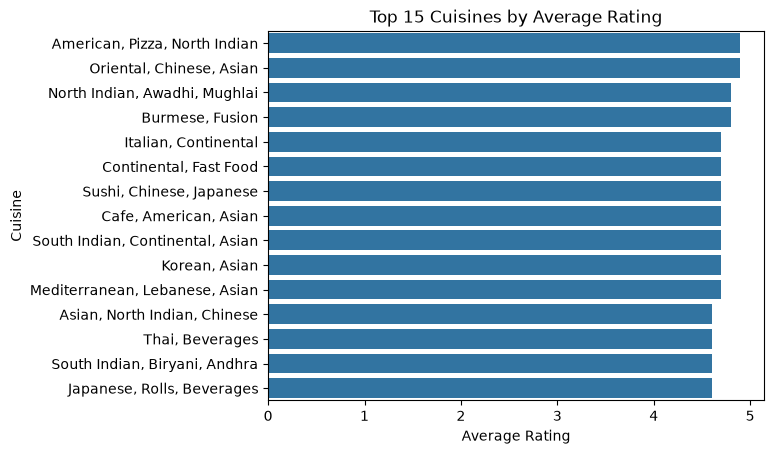

In [14]:
cuisine_rating = (
    df.groupby('Cuisine')['Rating']
      .mean()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

sns.barplot(
    data=cuisine_rating,
    x='Rating',
    y='Cuisine'
)

plt.title('Top 15 Cuisines by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.show()

# Most Popular Cuisines — Count Plot

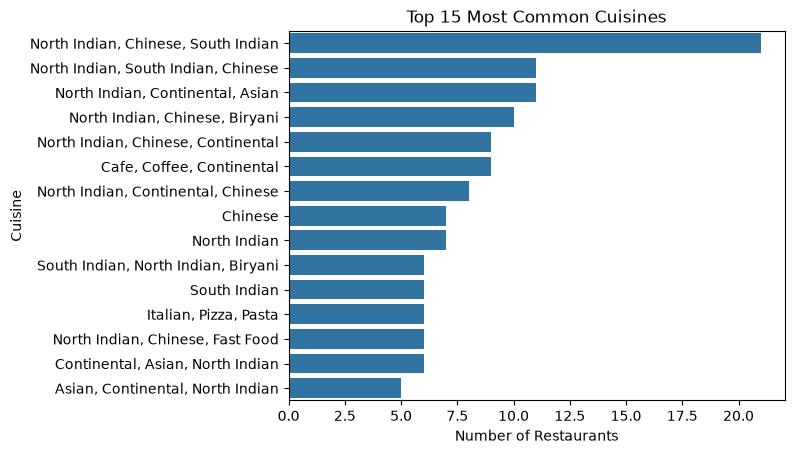

In [15]:
top_cuisines = df['Cuisine'].value_counts().head(15)

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title('Top 15 Most Common Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.show()

# Reviews vs Rating — Scatter Plot

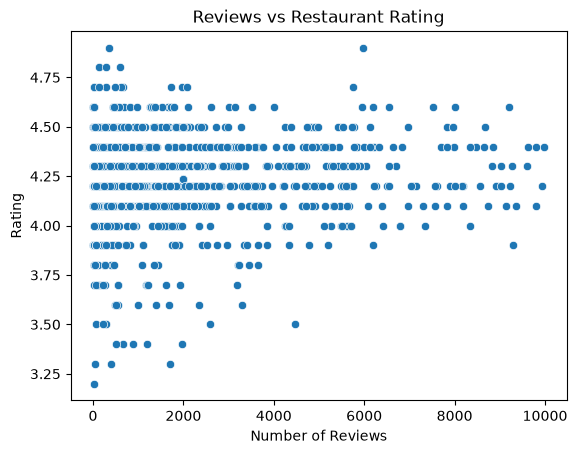

In [16]:
sns.scatterplot(
    data=df,
    x='Reviews',
    y='Rating'
)

plt.title('Reviews vs Restaurant Rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.show()

# Top Restaurants by Reviews

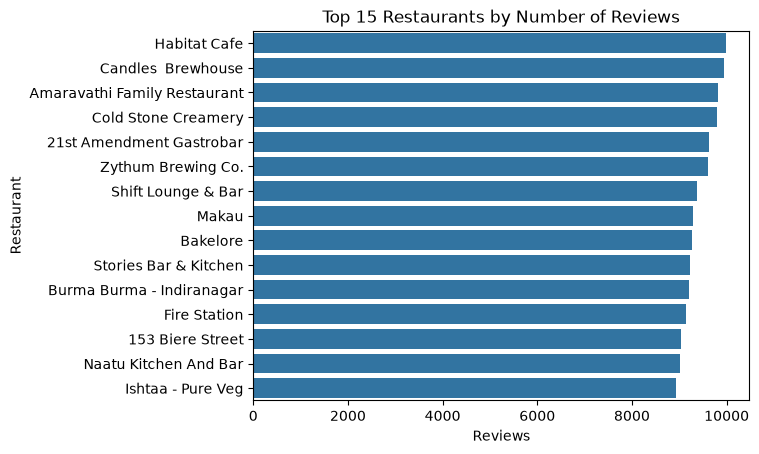

In [17]:
top_reviews = df.nlargest(15, 'Reviews')

sns.barplot(
    data=top_reviews,
    x='Reviews',
    y='Restaurant Name'
)

plt.title('Top 15 Restaurants by Number of Reviews')
plt.xlabel('Reviews')
plt.ylabel('Restaurant')
plt.show()

# Average Rating by City

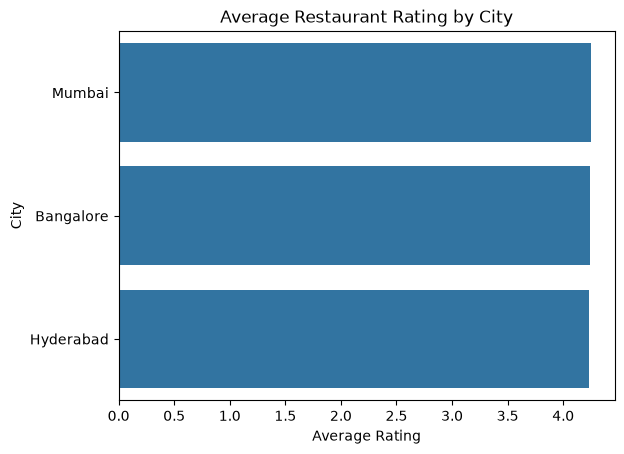

In [18]:
city_rating = (
    df.groupby('City')['Rating']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

sns.barplot(
    data=city_rating,
    x='Rating',
    y='City'
)

plt.title('Average Restaurant Rating by City')
plt.xlabel('Average Rating')
plt.ylabel('City')
plt.show()

# Number of Restaurants by City

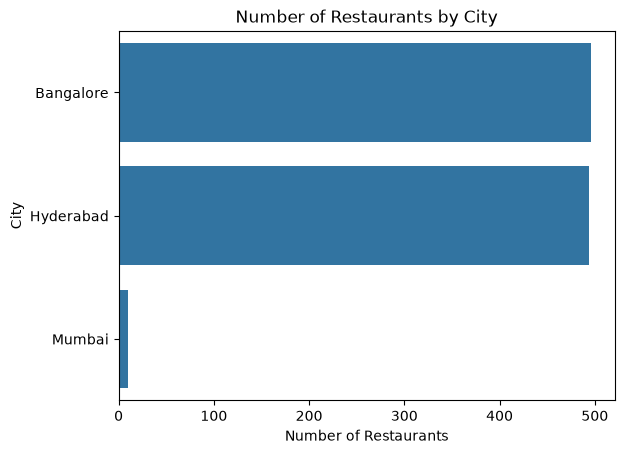

In [19]:
city_count = df['City'].value_counts()

sns.barplot(
    x=city_count.values,
    y=city_count.index
)

plt.title('Number of Restaurants by City')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.show()

# Reviews Distribution

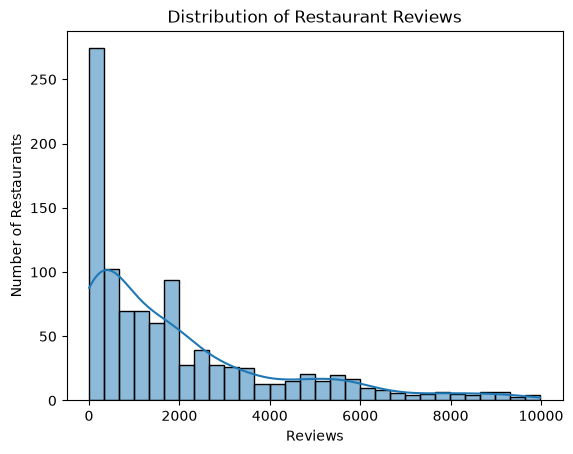

In [20]:
sns.histplot(data=df, x='Reviews', bins=30, kde=True)

plt.title('Distribution of Restaurant Reviews')
plt.xlabel('Reviews')
plt.ylabel('Number of Restaurants')
plt.show()

# Rating vs Reviews

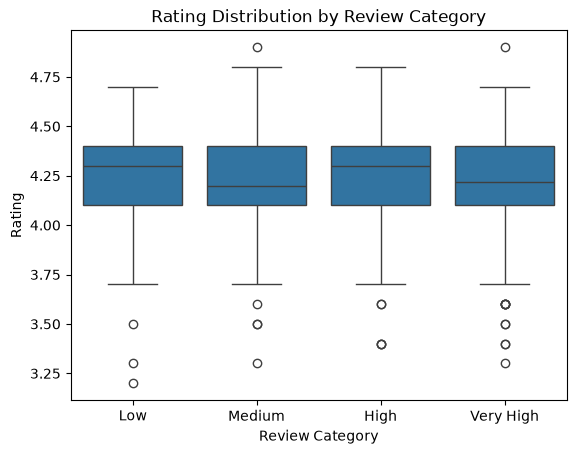

In [21]:
df['Review_Category'] = pd.cut(
    df['Reviews'],
    bins=[0, 100, 500, 1000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

sns.boxplot(
    data=df,
    x='Review_Category',
    y='Rating'
)

plt.title('Rating Distribution by Review Category')
plt.xlabel('Review Category')
plt.ylabel('Rating')
plt.show()

# Top 10 Restaurants by Rating

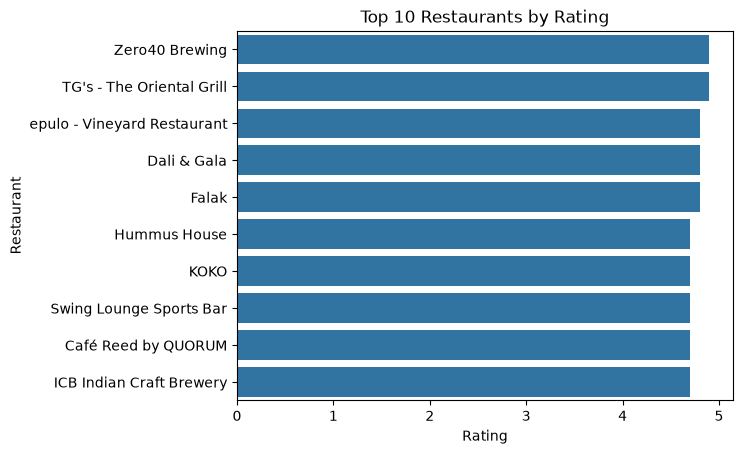

In [22]:
top_rating = df.nlargest(10, 'Rating')

sns.barplot(
    data=top_rating,
    x='Rating',
    y='Restaurant Name'
)

plt.title('Top 10 Restaurants by Rating')
plt.xlabel('Rating')
plt.ylabel('Restaurant')
plt.show()